Importing

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    classification_report
)

Loading Risk Scores

In [2]:
risk_scores = pd.read_csv(
    "/run/media/aditya-anurag/New Volume/Self/Personal/Project/Credit Risk Intelligence & Default Prediction/outputs/predictions/risk_scores.csv"
)

risk_scores.head()

,actual,probability_default,risk_band
0,0,0.179421,Very Low Risk
1,0,0.156426,Very Low Risk
2,0,0.019365,Very Low Risk
3,0,0.353887,Low Risk
4,1,0.179403,Very Low Risk


Inspect Probability Distribution

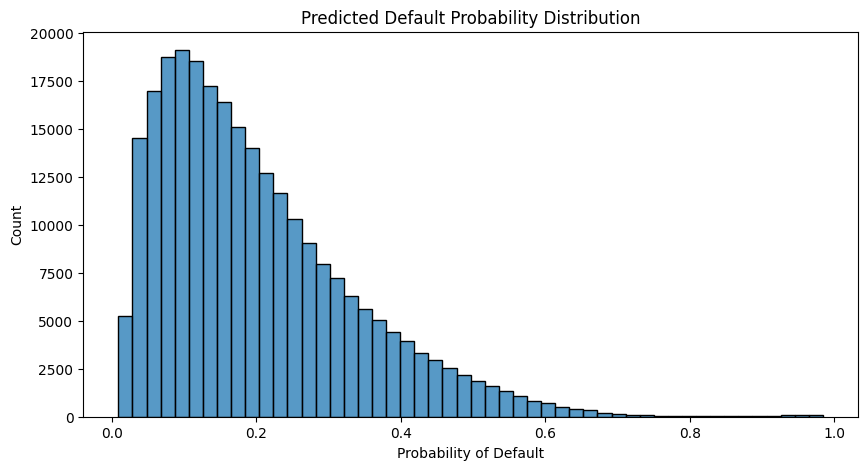

In [3]:
plt.figure(figsize=(10,5))

sns.histplot(
    risk_scores['probability_default'],
    bins=50
)

plt.title('Predicted Default Probability Distribution')

plt.xlabel('Probability of Default')

plt.show()

Creating Predictions

In [4]:
risk_scores['pred_50'] = np.where(
    risk_scores['probability_default'] >= 0.5,
    1,
    0
)

In [5]:
#Evaluation
print(
    "Precision:",
    precision_score(
        risk_scores['actual'],
        risk_scores['pred_50']
    )
)

print(
    "Recall:",
    recall_score(
        risk_scores['actual'],
        risk_scores['pred_50']
    )
)

print(
    "F1:",
    f1_score(
        risk_scores['actual'],
        risk_scores['pred_50']
    )
)

Precision: 0.6070553127997442
Recall: 0.10884561732051748
F1: 0.18459344719188514


Creating Threshold Evaluation Loop

In [6]:
threshold_results = []

thresholds = np.arange(
    0.1,
    1.0,
    0.05
)

In [7]:
#Loop
for threshold in thresholds:

    preds = np.where(
        risk_scores['probability_default'] >= threshold,
        1,
        0
    )

    precision = precision_score(
        risk_scores['actual'],
        preds
    )

    recall = recall_score(
        risk_scores['actual'],
        preds
    )

    f1 = f1_score(
        risk_scores['actual'],
        preds
    )

    threshold_results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    })

In [8]:
#Converting to dataframe
threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df.head()

,threshold,precision,recall,f1_score
0,0.10,0.249977,0.921309,0.393253
1,0.15,0.289778,0.812769,0.427233
2,0.20,0.332200,0.685215,0.447464
3,0.25,0.376049,0.552961,0.447661
4,0.30,0.419394,0.432000,0.425604


Visualizing Threshold Tradeoffs

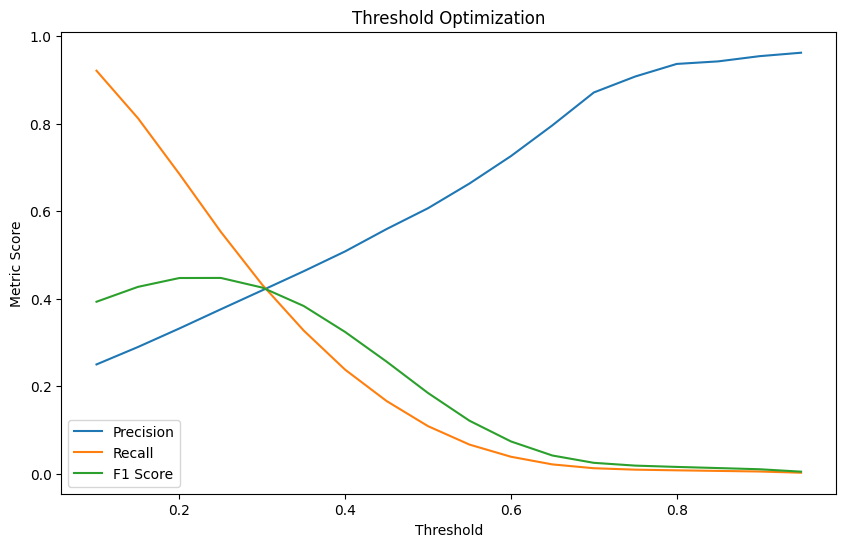

In [9]:
plt.figure(figsize=(10,6))

plt.plot(
    threshold_df['threshold'],
    threshold_df['precision'],
    label='Precision'
)

plt.plot(
    threshold_df['threshold'],
    threshold_df['recall'],
    label='Recall'
)

plt.plot(
    threshold_df['threshold'],
    threshold_df['f1_score'],
    label='F1 Score'
)

plt.xlabel('Threshold')

plt.ylabel('Metric Score')

plt.title('Threshold Optimization')

plt.legend()

plt.show()

In [10]:
selected_threshold = 0.40

In [11]:
#Final Predictions
risk_scores['final_prediction'] = np.where(
    risk_scores['probability_default'] >= selected_threshold,
    1,
    0
)

Final Metrics

In [12]:
print(
    classification_report(
        risk_scores['actual'],
        risk_scores['final_prediction']
    )
)

              precision    recall  f1-score   support

           0       0.83      0.94      0.88    208391
           1       0.51      0.24      0.32     52331

    accuracy                           0.80    260722
   macro avg       0.67      0.59      0.60    260722
weighted avg       0.77      0.80      0.77    260722



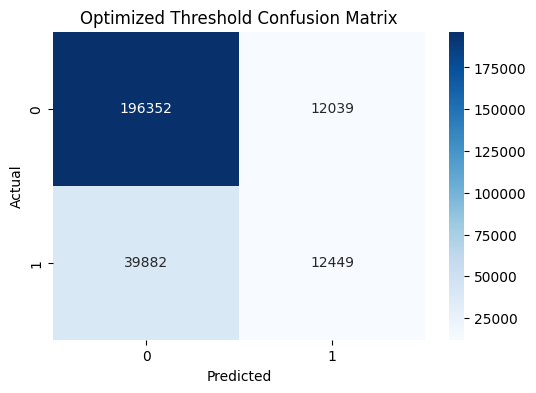

In [13]:
#Confusion Matrix
cm = confusion_matrix(
    risk_scores['actual'],
    risk_scores['final_prediction']
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Optimized Threshold Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

Building Decision Framework

In [14]:
def assign_decision(prob):

    if prob < 0.20:
        return 'Approve'

    elif prob < 0.50:
        return 'Manual Review'

    else:
        return 'Reject'

In [15]:
risk_scores['decision'] = (
    risk_scores['probability_default']
    .apply(assign_decision)
)

Decision Distribution

In [16]:
risk_scores['decision'].value_counts()

decision
Approve          152781
Manual Review     98558
Reject             9383
Name: count, dtype: int64

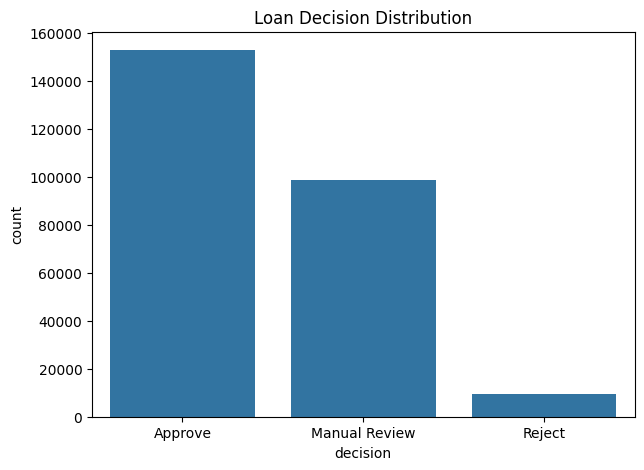

In [17]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='decision',
    data=risk_scores
)

plt.title('Loan Decision Distribution')

plt.show()

Decision Quality Analysis

In [18]:
decision_default_rate = (
    risk_scores.groupby('decision')['actual']
    .mean()
    * 100
)

decision_default_rate

decision
Approve          10.782100
Manual Review    30.603300
Reject           60.705531
Name: actual, dtype: float64

Portfolio Risk Summary

In [19]:
portfolio_summary = risk_scores.groupby(
    'decision'
).agg({
    'probability_default': ['mean', 'count'],
    'actual': 'mean'
})

portfolio_summary

probability_default            actual
                             mean   count      mean
decision                                           
Approve                  0.109918  152781  0.107821
Manual Review            0.305334   98558  0.306033
Reject                   0.586495    9383  0.607055

Creating Borrower scorecard view

In [20]:
scorecard = risk_scores.copy()

In [21]:
scorecard['risk_score'] = (
    (1 - scorecard['probability_default'])
    * 1000
).astype(int)

In [22]:
scorecard = scorecard[
    [
        'risk_score',
        'probability_default',
        'risk_band',
        'decision',
        'actual'
    ]
]

scorecard.head(20)

,risk_score,probability_default,risk_band,decision,actual
0,820,0.179421,Very Low Risk,Approve,0
1,843,0.156426,Very Low Risk,Approve,0
2,980,0.019365,Very Low Risk,Approve,0
3,646,0.353887,Low Risk,Manual Review,0
4,820,0.179403,Very Low Risk,Approve,1
5,744,0.255280,Low Risk,Manual Review,0
6,496,0.503901,Medium Risk,Reject,0
7,960,0.039742,Very Low Risk,Approve,0
8,703,0.296727,Low Risk,Manual Review,0
9,760,0.239306,Low Risk,Manual Review,0


In [23]:
threshold_df.to_csv(
    "/run/media/aditya-anurag/New Volume/Self/Personal/Project/Credit Risk Intelligence & Default Prediction/outputs/predictions/threshold_metrics.csv",
    index=False
)

Saving Portfolio Summary

In [24]:
portfolio_summary.to_csv(
    "/run/media/aditya-anurag/New Volume/Self/Personal/Project/Credit Risk Intelligence & Default Prediction/outputs/predictions/portfolio_summary.csv",
    index=False
)

Saving Decision Default Rate

In [25]:
decision_default_rate.to_csv(
    "/run/media/aditya-anurag/New Volume/Self/Personal/Project/Credit Risk Intelligence & Default Prediction/outputs/predictions/decision_default_rate.csv",
    index=False
)

Saving Scorecard

In [26]:
scorecard.to_csv(
    "/run/media/aditya-anurag/New Volume/Self/Personal/Project/Credit Risk Intelligence & Default Prediction/outputs/predictions/borrower_scorecard.csv",
    index=False
)

# Threshold Optimization & Decision Framework

## Objective

In real-world credit risk systems, model probabilities are not used directly for lending decisions.

Financial institutions must determine:
- which borrowers should be approved,
- which borrowers require additional review,
- and which borrowers should be rejected.

This phase focused on converting raw default probabilities into an operational decision-support framework.

---

# Threshold Optimization Analysis

The probability threshold directly impacts:
- precision,
- recall,
- approval quality,
- and portfolio risk exposure.

Lower thresholds increase:
- default detection capability,
- but also increase false positives.

Higher thresholds improve:
- approval precision,
- but may fail to identify risky borrowers.

The threshold optimization analysis demonstrated a clear tradeoff between:
- bad-loan capture,
- and unnecessary rejection of good borrowers.

---

# Threshold Performance Insights

Key observations from threshold analysis:

| Threshold | Precision | Recall | F1 Score |
|---|---|---|---|
| 0.10 | ~0.25 | ~0.92 | ~0.39 |
| 0.20 | ~0.33 | ~0.69 | ~0.45 |
| 0.25 | ~0.38 | ~0.55 | ~0.45 |
| 0.40 | ~0.51 | ~0.24 | ~0.32 |
| 0.50 | ~0.61 | ~0.11 | ~0.18 |

The results show that:
- lower thresholds prioritize risk detection,
- while higher thresholds prioritize lending precision.

A threshold near the lower-to-mid probability range provided the best balance between:
- recall,
- precision,
- and operational practicality.

---

# Probability Distribution Analysis

The predicted probability distribution showed that:
- most borrowers concentrated within lower-to-moderate risk ranges,
- while a smaller subset exhibited significantly elevated default probability.

This reflects realistic lending portfolio behavior where:
- the majority of borrowers are relatively stable,
- but a smaller high-risk segment contributes disproportionately to default exposure.

---

# Optimized Model Performance

After threshold optimization:
- the system achieved balanced portfolio segmentation,
- while maintaining meaningful bad-loan detection capability.

Final optimized classification performance:

- Accuracy: ~80%
- Default Recall: ~24%
- Default Precision: ~51%

Although recall declined at stricter thresholds, the model significantly improved:
- approval quality,
- risk concentration,
- and rejection precision.

This demonstrates the tradeoff between:
- portfolio growth,
- and credit risk protection.

---

# Operational Decision Framework

The model probabilities were converted into practical underwriting decisions:

| Probability Range | Decision |
|---|---|
| < 20% | Approve |
| 20% – 50% | Manual Review |
| > 50% | Reject |

This structure resembles real-world underwriting systems where:
- low-risk borrowers are auto-approved,
- borderline applicants undergo manual verification,
- and high-risk borrowers are declined.

---

# Decision Distribution

The portfolio was segmented into:

| Decision | Borrower Count |
|---|---|
| Approve | ~152,781 |
| Manual Review | ~98,558 |
| Reject | ~9,383 |

This demonstrates that the framework avoids:
- excessive rejection rates,
- while still isolating high-risk borrower groups.

---

# Decision Quality Analysis

Observed default rates by decision category:

| Decision | Observed Default Rate |
|---|---|
| Approve | ~10.8% |
| Manual Review | ~30.6% |
| Reject | ~60.7% |

This is one of the strongest validations of the system.

The framework successfully separated borrowers into:
- low-risk,
- moderate-risk,
- and high-risk segments.

The rejected segment exhibited a materially elevated realized default rate, indicating that the model effectively identified high-risk lending candidates.

---

# Portfolio Risk Segmentation

Portfolio-level analysis showed strong alignment between:
- predicted risk,
- and realized default behavior.

Average predicted default probability by decision segment:

| Decision | Avg Predicted Default Probability |
|---|---|
| Approve | ~11% |
| Manual Review | ~31% |
| Reject | ~59% |

This demonstrates strong calibration consistency between:
- model output,
- and observed borrower outcomes.

---

# Borrower Scorecard System

A scorecard-style framework was developed using:
- probability of default,
- risk bands,
- lending decision category,
- and borrower risk score.

The generated risk score provides:
- an interpretable borrower ranking mechanism,
- suitable for portfolio monitoring and underwriting support.

Example outputs included:
- borrower risk score,
- default probability,
- risk category,
- approval recommendation,
- and realized outcome.

---

# Business Interpretation

The threshold optimization and decision framework demonstrate how predictive analytics can support operational lending workflows.

The system enables:
- borrower prioritization,
- risk-adjusted decisioning,
- portfolio segmentation,
- and early identification of high-risk applicants.

The project highlights the importance of balancing:
- growth objectives,
- underwriting quality,
- and default-risk management.

---

# Final Outcome
The completed framework now includes:
- probability-based risk scoring,
- operational threshold optimization,
- borrower-level decision logic,
- and portfolio-oriented risk segmentation.